In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df=pd.read_csv("/content/netflix_titles.csv")

In [4]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [10]:
df.shape


(8807, 12)

In [12]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [14]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [15]:
df.columns=df.columns.str.strip().str.lower().str.replace(" ","_")

In [16]:
df["date_added"] = pd.to_datetime(df["date_added"], errors="coerce")

In [18]:
df=df.drop_duplicates()

In [19]:
df["year_added"] = df["date_added"].dt.year
df["month_added"] = df["date_added"].dt.month_name()

In [20]:
content_type = df["type"].value_counts()
content_type

,count
type,
Movie,6131
TV Show,2676


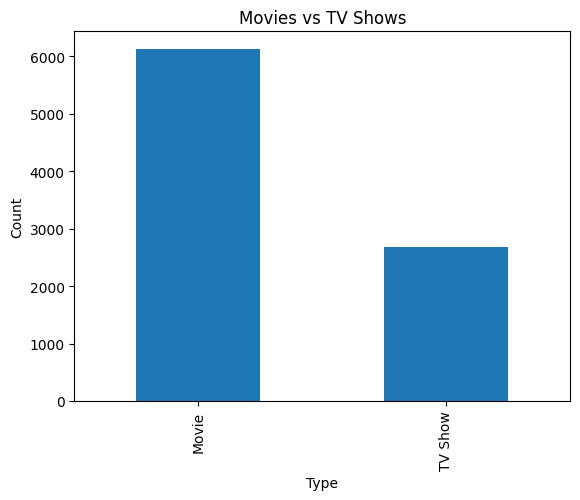

In [21]:
content_type.plot(kind="bar")
plt.title("Movies vs TV Shows")
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()

In [22]:
yearly_added = df["year_added"].value_counts().sort_index()
yearly_added

,count
year_added,
2008.0,2
2009.0,2
2010.0,1
2011.0,13
2012.0,3
2013.0,10
2014.0,23
2015.0,73
2016.0,418


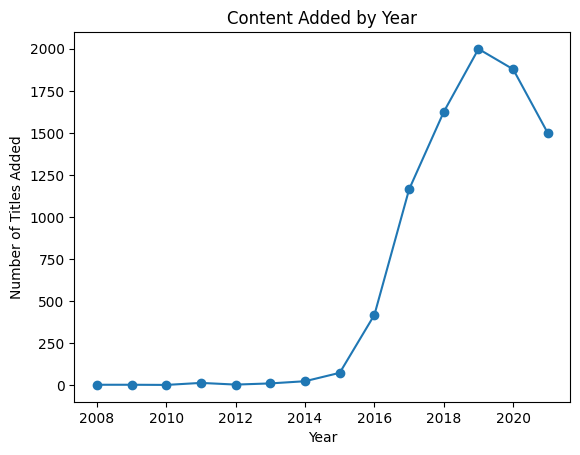

In [23]:
yearly_added.plot(marker="o")
plt.title("Content Added by Year")
plt.xlabel("Year")
plt.ylabel("Number of Titles Added")
plt.show()

In [24]:
country_counts = df["country"].dropna().str.split(", ").explode().value_counts().head(10)
country_counts

,count
country,
United States,3689
India,1046
United Kingdom,804
Canada,445
France,393
Japan,318
Spain,232
South Korea,231
Germany,226


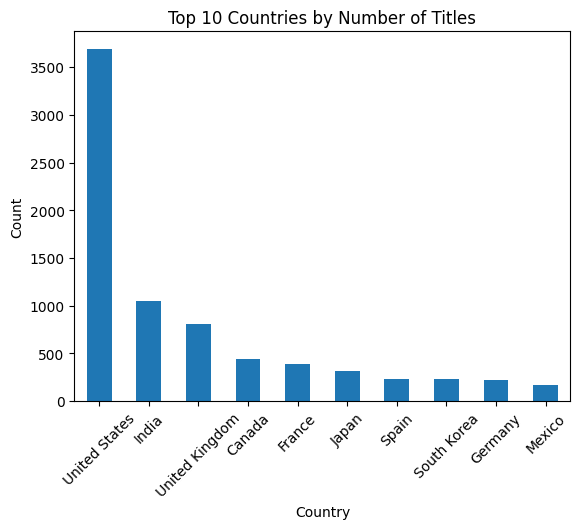

In [25]:
country_counts.plot(kind="bar")
plt.title("Top 10 Countries by Number of Titles")
plt.xlabel("Country")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

In [26]:
genre_counts = df["listed_in"].str.split(", ").explode().value_counts().head(10)
genre_counts

,count
listed_in,
International Movies,2752
Dramas,2427
Comedies,1674
International TV Shows,1351
Documentaries,869
Action & Adventure,859
TV Dramas,763
Independent Movies,756
Children & Family Movies,641


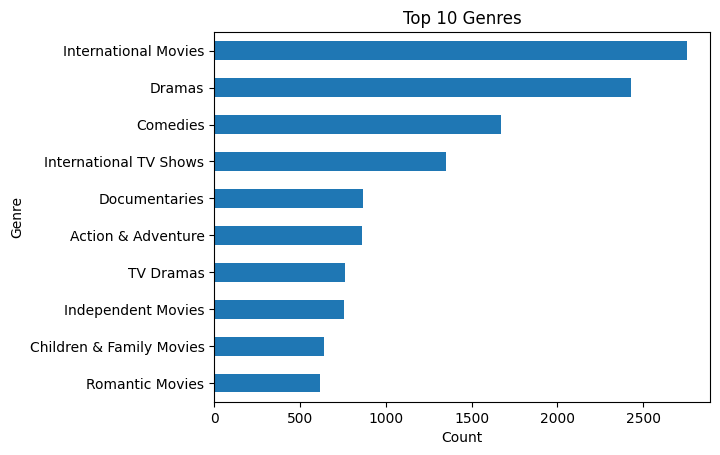

In [27]:
genre_counts.plot(kind="barh")
plt.title("Top 10 Genres")
plt.xlabel("Count")
plt.ylabel("Genre")
plt.gca().invert_yaxis()
plt.show()

In [28]:
rating_counts = df["rating"].value_counts().head(10)
rating_counts

,count
rating,
TV-MA,3207
TV-14,2160
TV-PG,863
R,799
PG-13,490
TV-Y7,334
TV-Y,307
PG,287
TV-G,220


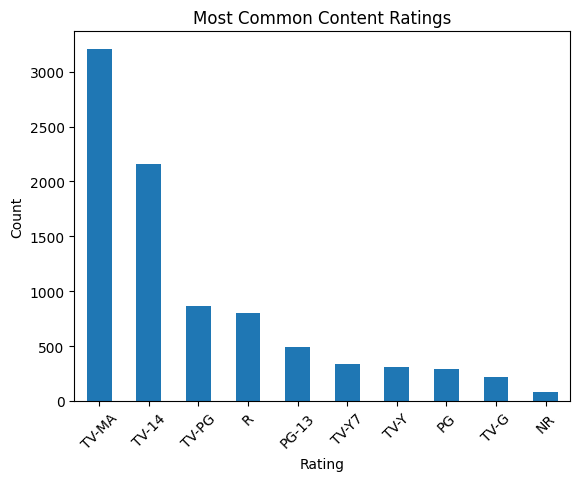

In [29]:
rating_counts.plot(kind="bar")
plt.title("Most Common Content Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

In [30]:
movies = df[df["type"] == "Movie"].copy()
movies["duration_int"] = movies["duration"].str.replace(" min", "", regex=False)
movies["duration_int"] = pd.to_numeric(movies["duration_int"], errors="coerce")

In [31]:
movies["duration_int"].describe()

,duration_int
count,6128.000000
mean,99.577187
std,28.290593
min,3.000000
25%,87.000000
50%,98.000000
75%,114.000000
max,312.000000


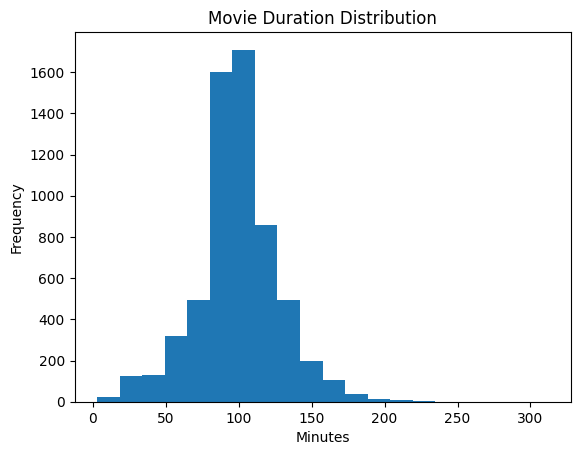

In [32]:
movies["duration_int"].plot(kind="hist", bins=20)
plt.title("Movie Duration Distribution")
plt.xlabel("Minutes")
plt.ylabel("Frequency")
plt.show()

In [33]:
director_counts = df["director"].dropna().value_counts().head(10)
director_counts

,count
director,
Rajiv Chilaka,19
"Raúl Campos, Jan Suter",18
Suhas Kadav,16
Marcus Raboy,16
Jay Karas,14
Cathy Garcia-Molina,13
Martin Scorsese,12
Youssef Chahine,12
Jay Chapman,12


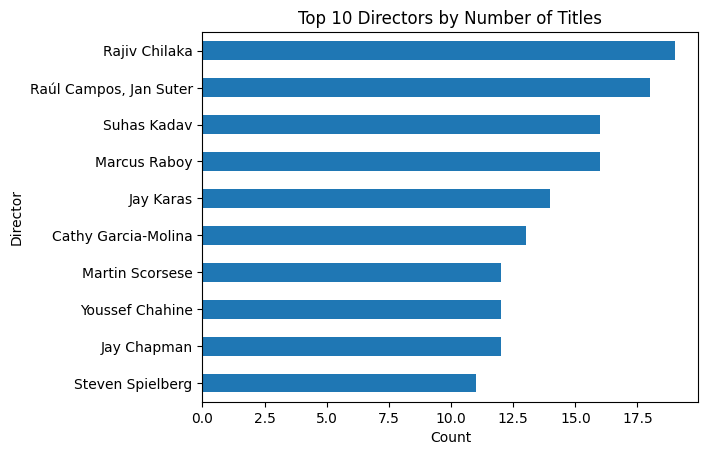

In [34]:
director_counts.plot(kind="barh")
plt.title("Top 10 Directors by Number of Titles")
plt.xlabel("Count")
plt.ylabel("Director")
plt.gca().invert_yaxis()
plt.show()

In [35]:
df[["release_year", "year_added"]].dropna().head()

,release_year,year_added
0,2020,2021.0
1,2021,2021.0
2,2021,2021.0
3,2021,2021.0
4,2021,2021.0


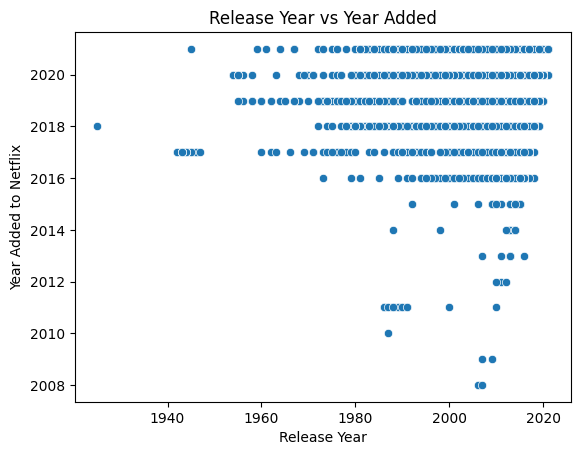

In [36]:
sns.scatterplot(data=df, x="release_year", y="year_added")
plt.title("Release Year vs Year Added")
plt.xlabel("Release Year")
plt.ylabel("Year Added to Netflix")
plt.show()

In [37]:
total_titles = len(df)
movie_count = (df["type"] == "Movie").sum()
tv_count = (df["type"] == "TV Show").sum()
top_country = df["country"].dropna().str.split(", ").explode().value_counts().idxmax()
top_genre = df["listed_in"].str.split(", ").explode().value_counts().idxmax()

print("Key Findings")
print(f"Total Titles: {total_titles}")
print(f"Movies: {movie_count}")
print(f"TV Shows: {tv_count}")
print(f"Top Country: {top_country}")
print(f"Top Genre: {top_genre}")

Key Findings
Total Titles: 8807
Movies: 6131
TV Shows: 2676
Top Country: United States
Top Genre: International Movies
